# 1. Assignment Overview


Notebook này xây pipeline Assignment 04 cho đúng bài toán CNN image classification trên MNIST: ảnh chữ số viết tay 28x28 grayscale, 10 classes. Notebook tập trung vào representation ảnh, convolution operations, NumPy CNN from scratch, Keras CNN, PyTorch CNN, so sánh framework và phân tích lỗi dự đoán.

In [1]:
from pathlib import Path
import json
import pandas as pd

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "datasets").exists() and (path / "pipeline04").exists():
            return path
    raise FileNotFoundError("Cannot locate project root.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "datasets" / "mnist"
ARTIFACT_DIR = PROJECT_ROOT / "pipeline04" / "mnist"
MODEL_DIR = ARTIFACT_DIR / "models"
METRIC_DIR = ARTIFACT_DIR / "metrics"
FIGURE_DIR = ARTIFACT_DIR / "figures"
METADATA_DIR = ARTIFACT_DIR / "metadata"
for directory in [DATA_DIR, MODEL_DIR, METRIC_DIR, FIGURE_DIR, METADATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

overview = {
    "Dataset": "MNIST",
    "Source": "TensorFlow/Keras official MNIST archive",
    "Task": "Image classification",
    "Image representation": "28 x 28 grayscale",
    "Classes": 10,
    "Notebook role": "Style reference for CIFAR-10 CNN notebook",
}
pd.DataFrame([overview]).T.rename(columns={0: "Value"})


,Value
Dataset,MNIST
Source,TensorFlow/Keras official MNIST archive
Task,Image classification
Image representation,28 x 28 grayscale
Classes,10
Notebook role,Style reference for CIFAR-10 CNN notebook


**Nhận xét kết quả.**

- Bảng overview xác nhận notebook dùng MNIST image data thật, không còn dùng tabular dataset.
- Các artifact của phase MNIST được tách dưới `pipeline04/mnist/`.

# 2. Environment Setup


Import thư viện, cố định seed, kiểm tra version TensorFlow/PyTorch và xác định device. Output chỉ dùng thông tin môi trường cần thiết, không in path cá nhân.

In [2]:
import os
import random
import time
import warnings
import urllib.request
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.get_logger().setLevel("ERROR")
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = [str(i) for i in range(10)]

env_info = {
    "Python executable": Path(os.sys.executable).name,
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "TensorFlow": tf.__version__,
    "PyTorch": torch.__version__,
    "TensorFlow GPUs": len(tf.config.list_physical_devices("GPU")),
    "PyTorch device": str(DEVICE),
    "Seed": SEED,
}
pd.DataFrame([env_info]).T.rename(columns={0: "Value"})


,Value
Python executable,python.exe
NumPy,1.26.4
Pandas,2.2.3
scikit-learn,1.5.2
TensorFlow,2.18.0
PyTorch,2.5.1+cpu
TensorFlow GPUs,0
PyTorch device,cpu
Seed,42


**Nhận xét kết quả.**

- Output cho biết notebook đang chạy bằng CPU hay GPU và version các framework.
- Seed được cố định để các split, initialization và DataLoader reproducible hơn.

# 3. Load Dataset


Load MNIST từ file cache trong `datasets/mnist/`. Nếu file chưa có, code có cơ chế tải lại từ TensorFlow/Keras official archive.

In [3]:
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
MNIST_PATH = DATA_DIR / "mnist.npz"

if not MNIST_PATH.exists():
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)

with np.load(MNIST_PATH) as data:
    x_train_full = data["x_train"]
    y_train_full = data["y_train"]
    x_test_raw = data["x_test"]
    y_test = data["y_test"]

load_summary = {
    "Cache file": MNIST_PATH.relative_to(PROJECT_ROOT).as_posix(),
    "Cache size MB": round(MNIST_PATH.stat().st_size / (1024 * 1024), 3),
    "x_train shape": x_train_full.shape,
    "y_train shape": y_train_full.shape,
    "x_test shape": x_test_raw.shape,
    "y_test shape": y_test.shape,
    "Image dtype": str(x_train_full.dtype),
    "Pixel min": int(x_train_full.min()),
    "Pixel max": int(x_train_full.max()),
    "Number of classes": int(np.unique(y_train_full).size),
}
pd.DataFrame([load_summary]).T.rename(columns={0: "Value"})


,Value
Cache file,datasets/mnist/mnist.npz
Cache size MB,10.958
x_train shape,"(60000, 28, 28)"
y_train shape,"(60000,)"
x_test shape,"(10000, 28, 28)"
y_test shape,"(10000,)"
Image dtype,uint8
Pixel min,0
Pixel max,255
Number of classes,10


**Nhận xét kết quả.**

- MNIST cache nằm tại `datasets/mnist/mnist.npz`, kích thước khoảng 10.96 MB.
- Dataset load được 60,000 ảnh train gốc và 10,000 ảnh test; mỗi ảnh là grayscale 28x28 với 10 class.
- Pixel ban đầu ở thang 0-255, nên cần normalize trước khi train CNN.

# 4. Dataset Inspection


Kiểm tra phân phối class, hiển thị sample images và inspect một ảnh cụ thể để hiểu dữ liệu ảnh trước khi chuẩn hóa.

,Class,TrainCount,TrainRate,TestCount,TestRate
0,0,5923,0.0987,980,0.0980
1,1,6742,0.1124,1135,0.1135
2,2,5958,0.0993,1032,0.1032
3,3,6131,0.1022,1010,0.1010
4,4,5842,0.0974,982,0.0982
5,5,5421,0.0904,892,0.0892
6,6,5918,0.0986,958,0.0958
7,7,6265,0.1044,1028,0.1028
8,8,5851,0.0975,974,0.0974
9,9,5949,0.0992,1009,0.1009


,Value
Sample index,0
Shape,"(28, 28)"
Dtype,uint8
Min,0
Max,255
Label,5


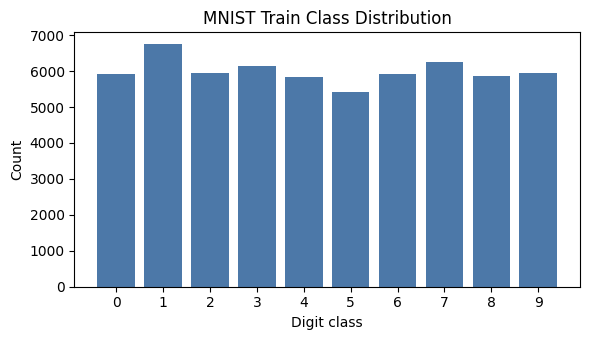

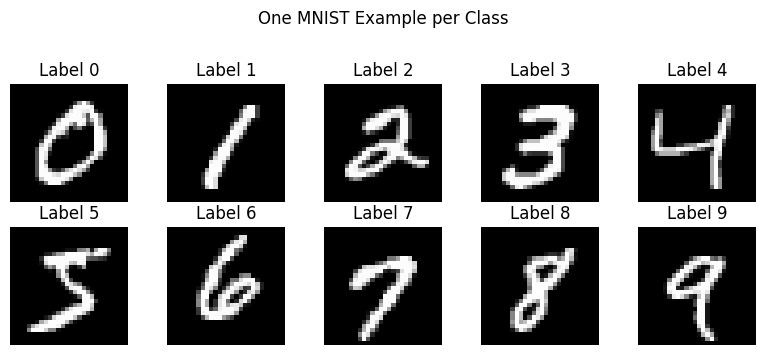

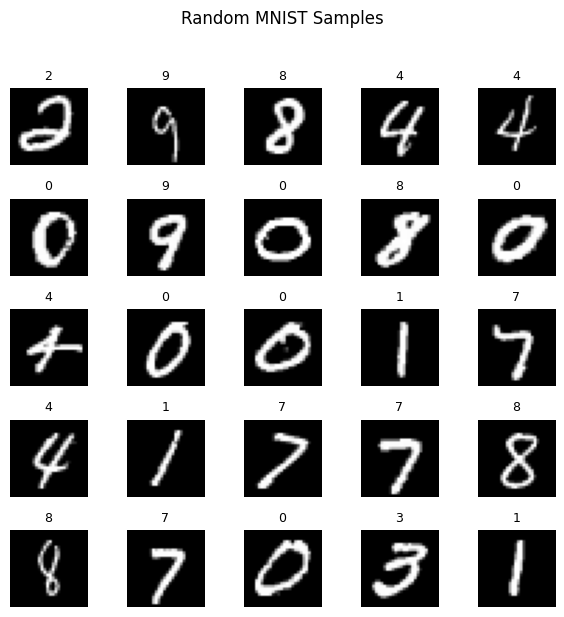

In [4]:
train_counts = np.bincount(y_train_full, minlength=10)
test_counts = np.bincount(y_test, minlength=10)
class_distribution = pd.DataFrame({
    "Class": np.arange(10),
    "TrainCount": train_counts,
    "TrainRate": train_counts / len(y_train_full),
    "TestCount": test_counts,
    "TestRate": test_counts / len(y_test),
})

sample_index = 0
sample_info = {
    "Sample index": sample_index,
    "Shape": x_train_full[sample_index].shape,
    "Dtype": str(x_train_full[sample_index].dtype),
    "Min": int(x_train_full[sample_index].min()),
    "Max": int(x_train_full[sample_index].max()),
    "Label": int(y_train_full[sample_index]),
}

display(class_distribution.round(4))
display(pd.DataFrame([sample_info]).T.rename(columns={0: "Value"}))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(class_distribution["Class"].astype(str), class_distribution["TrainCount"], color="#4C78A8")
ax.set_title("MNIST Train Class Distribution")
ax.set_xlabel("Digit class")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class_distribution.png", dpi=160)
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(8, 3.4))
for digit, ax in enumerate(axes.ravel()):
    idx = np.where(y_train_full == digit)[0][0]
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(f"Label {digit}")
    ax.axis("off")
fig.suptitle("One MNIST Example per Class", y=1.03)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "one_example_per_class.png", dpi=160)
plt.show()

rng = np.random.default_rng(SEED)
sample_ids = rng.choice(len(x_train_full), size=25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for idx, ax in zip(sample_ids, axes.ravel()):
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(str(int(y_train_full[idx])), fontsize=9)
    ax.axis("off")
fig.suptitle("Random MNIST Samples", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sample_grid.png", dpi=160)
plt.show()


**Nhận xét kết quả.**

- Class distribution giúp kiểm tra MNIST có đủ 10 chữ số và không bị lệch class nghiêm trọng.
- Các grid ảnh cho thấy input là chữ số viết tay grayscale, đúng loại dữ liệu mà Conv2D có cơ sở dùng.

# 5. Data Preparation


Tạo train/validation/test split, normalize pixel và chuẩn bị hai layout tensor: Keras dùng channels-last, PyTorch dùng channels-first.

In [5]:
x_train_raw, x_valid_raw, y_train, y_valid = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full,
)

X_train_keras = (x_train_raw.astype("float32") / 255.0)[..., np.newaxis]
X_valid_keras = (x_valid_raw.astype("float32") / 255.0)[..., np.newaxis]
X_test_keras = (x_test_raw.astype("float32") / 255.0)[..., np.newaxis]

X_train_torch = np.transpose(X_train_keras, (0, 3, 1, 2))
X_valid_torch = np.transpose(X_valid_keras, (0, 3, 1, 2))
X_test_torch = np.transpose(X_test_keras, (0, 3, 1, 2))

split_summary = pd.DataFrame([
    {"Split": "train", "Images": len(y_train), "Shape": X_train_keras.shape, "PixelMin": float(X_train_keras.min()), "PixelMax": float(X_train_keras.max())},
    {"Split": "validation", "Images": len(y_valid), "Shape": X_valid_keras.shape, "PixelMin": float(X_valid_keras.min()), "PixelMax": float(X_valid_keras.max())},
    {"Split": "test", "Images": len(y_test), "Shape": X_test_keras.shape, "PixelMin": float(X_test_keras.min()), "PixelMax": float(X_test_keras.max())},
])
layout_summary = pd.DataFrame([
    {"Framework": "Keras/TensorFlow", "Layout": "B x H x W x C", "TrainShape": X_train_keras.shape},
    {"Framework": "PyTorch", "Layout": "B x C x H x W", "TrainShape": X_train_torch.shape},
])

display(split_summary)
display(layout_summary)


,Split,Images,Shape,PixelMin,PixelMax
0,train,54000,"(54000, 28, 28, 1)",0.0,1.0
1,validation,6000,"(6000, 28, 28, 1)",0.0,1.0
2,test,10000,"(10000, 28, 28, 1)",0.0,1.0


,Framework,Layout,TrainShape
0,Keras/TensorFlow,B x H x W x C,"(54000, 28, 28, 1)"
1,PyTorch,B x C x H x W,"(54000, 1, 28, 28)"


**Nhận xét kết quả.**

- Validation được lấy từ original training set: train 54,000, validation 6,000, test 10,000.
- Normalize `/255` không học tham số từ validation/test, nên không tạo leakage.
- Keras dùng tensor `(B, 28, 28, 1)`, còn PyTorch dùng `(B, 1, 28, 28)`.

# 6. Discover CNN Operations


Chạy các operation CNN cơ bản trên tensor nhỏ: Conv2D, ReLU, MaxPool, Flatten, Dense, logits và softmax.

In [6]:
toy_input = tf.reshape(tf.range(1, 17, dtype=tf.float32), (1, 4, 4, 1))
toy_conv = layers.Conv2D(filters=2, kernel_size=3, padding="same", use_bias=True)
toy_conv_out = toy_conv(toy_input)
toy_relu_out = tf.nn.relu(toy_conv_out)
toy_pool_out = layers.MaxPooling2D(pool_size=2)(toy_relu_out)
toy_flat = layers.Flatten()(toy_pool_out)
toy_dense = layers.Dense(10)(toy_flat)
toy_softmax = tf.nn.softmax(toy_dense, axis=1)

cnn_operation_shapes = pd.DataFrame([
    {"Operation": "Input", "Shape": tuple(toy_input.shape)},
    {"Operation": "Conv2D(filters=2,kernel=3,padding=same)", "Shape": tuple(toy_conv_out.shape)},
    {"Operation": "ReLU", "Shape": tuple(toy_relu_out.shape)},
    {"Operation": "MaxPool2D(pool=2)", "Shape": tuple(toy_pool_out.shape)},
    {"Operation": "Flatten", "Shape": tuple(toy_flat.shape)},
    {"Operation": "Dense logits", "Shape": tuple(toy_dense.shape)},
    {"Operation": "Softmax probabilities", "Shape": tuple(toy_softmax.shape)},
])
display(cnn_operation_shapes)
print("Softmax sum:", float(tf.reduce_sum(toy_softmax).numpy()))


,Operation,Shape
0,Input,"(1, 4, 4, 1)"
1,"Conv2D(filters=2,kernel=3,padding=same)","(1, 4, 4, 2)"
2,ReLU,"(1, 4, 4, 2)"
3,MaxPool2D(pool=2),"(1, 2, 2, 2)"
4,Flatten,"(1, 8)"
5,Dense logits,"(1, 10)"
6,Softmax probabilities,"(1, 10)"


Softmax sum: 0.9999998211860657


**Nhận xét kết quả.**

- Conv2D giữ batch dimension và đổi channel từ 1 sang số filter.
- MaxPool giảm height/width, Flatten chuyển feature map thành vector, Dense tạo 10 logits cho 10 class.
- Softmax sum xấp xỉ 1, đúng tính chất phân phối xác suất.

# 7. Inspect CNN Building Blocks


Dùng một batch MNIST thật để kiểm tra shape qua từng building block trong cả Keras và PyTorch.

In [7]:
keras_probe = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(8, 3, padding="same", name="conv_probe"),
    layers.ReLU(name="relu_probe"),
    layers.MaxPooling2D(2, name="pool_probe"),
    layers.Flatten(name="flatten_probe"),
    layers.Dense(10, name="logits_probe"),
])
keras_batch = X_train_keras[:8]
keras_logits = keras_probe(keras_batch, training=False)

torch_probe = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(8 * 14 * 14, 10),
)
torch_batch = torch.tensor(X_train_torch[:8], dtype=torch.float32)
torch_logits = torch_probe(torch_batch)

probe_summary = pd.DataFrame([
    {"Framework": "Keras", "InputShape": keras_batch.shape, "LogitsShape": tuple(keras_logits.shape)},
    {"Framework": "PyTorch", "InputShape": tuple(torch_batch.shape), "LogitsShape": tuple(torch_logits.shape)},
])
display(probe_summary)


,Framework,InputShape,LogitsShape
0,Keras,"(8, 28, 28, 1)","(8, 10)"
1,PyTorch,"(8, 1, 28, 28)","(8, 10)"


**Nhận xét kết quả.**

- Một batch có 8 ảnh tạo ra 8 hàng logits, mỗi hàng có 10 giá trị cho 10 chữ số.
- Keras dùng `(B, H, W, C)`, còn PyTorch dùng `(B, C, H, W)`.

# 8. CNN From Scratch with NumPy


Định nghĩa các layer NumPy có forward/backward thật: Conv2D, ReLU, MaxPool2D, Flatten, Dense, SoftmaxCrossEntropy và SGD update.

In [8]:
def im2col_nhwc(x, kh, kw, pad=0, stride=1):
    x_pad = np.pad(x, ((0, 0), (pad, pad), (pad, pad), (0, 0)), mode="constant")
    b, h, w, c = x_pad.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    cols = np.empty((x.shape[0], out_h, out_w, kh, kw, c), dtype=x.dtype)
    for i in range(kh):
        for j in range(kw):
            cols[:, :, :, i, j, :] = x_pad[:, i:i + out_h * stride:stride, j:j + out_w * stride:stride, :]
    return cols.reshape(x.shape[0] * out_h * out_w, kh * kw * c), x_pad.shape, out_h, out_w

def col2im_nhwc(cols, x_shape, x_pad_shape, kh, kw, pad=0, stride=1):
    b, h, w, c = x_shape
    _, hp, wp, _ = x_pad_shape
    out_h = (hp - kh) // stride + 1
    out_w = (wp - kw) // stride + 1
    cols = cols.reshape(b, out_h, out_w, kh, kw, c)
    dx_pad = np.zeros(x_pad_shape, dtype=cols.dtype)
    for i in range(kh):
        for j in range(kw):
            dx_pad[:, i:i + out_h * stride:stride, j:j + out_w * stride:stride, :] += cols[:, :, :, i, j, :]
    return dx_pad[:, pad:pad + h, pad:pad + w, :] if pad else dx_pad

class Conv2DNumPy:
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, seed=0):
        rng = np.random.default_rng(seed)
        scale = np.sqrt(2.0 / (kernel_size * kernel_size * in_channels))
        self.W = (rng.normal(0, scale, (kernel_size, kernel_size, in_channels, out_channels))).astype("float32")
        self.b = np.zeros(out_channels, dtype="float32")
        self.padding = padding
        self.kernel_size = kernel_size
    def forward(self, x):
        self.x = x
        self.cols, self.x_pad_shape, out_h, out_w = im2col_nhwc(x, self.kernel_size, self.kernel_size, self.padding)
        out = self.cols @ self.W.reshape(-1, self.W.shape[-1]) + self.b
        return out.reshape(x.shape[0], out_h, out_w, self.W.shape[-1])
    def backward(self, dout):
        dout2 = dout.reshape(-1, dout.shape[-1])
        self.dW = (self.cols.T @ dout2).reshape(self.W.shape)
        self.db = dout2.sum(axis=0)
        dcols = dout2 @ self.W.reshape(-1, self.W.shape[-1]).T
        return col2im_nhwc(dcols, self.x.shape, self.x_pad_shape, self.kernel_size, self.kernel_size, self.padding)
    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

class ReLUNumPy:
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask
    def backward(self, dout):
        return dout * self.mask
    def update(self, lr):
        pass

class MaxPool2DNumPy:
    def __init__(self, pool=2, stride=2):
        self.pool = pool
        self.stride = stride
    def forward(self, x):
        self.x = x
        b, h, w, c = x.shape
        out_h, out_w = h // self.stride, w // self.stride
        out = np.empty((b, out_h, out_w, c), dtype=x.dtype)
        self.argmax = np.empty((b, out_h, out_w, c), dtype=np.int32)
        for i in range(out_h):
            for j in range(out_w):
                window = x[:, i*self.stride:i*self.stride+self.pool, j*self.stride:j*self.stride+self.pool, :]
                flat = window.reshape(b, self.pool * self.pool, c)
                self.argmax[:, i, j, :] = flat.argmax(axis=1)
                out[:, i, j, :] = flat.max(axis=1)
        return out
    def backward(self, dout):
        dx = np.zeros_like(self.x)
        b, out_h, out_w, c = dout.shape
        for i in range(out_h):
            for j in range(out_w):
                for n in range(b):
                    for ch in range(c):
                        pos = self.argmax[n, i, j, ch]
                        dx[n, i*self.stride + pos // self.pool, j*self.stride + pos % self.pool, ch] += dout[n, i, j, ch]
        return dx
    def update(self, lr):
        pass

class FlattenNumPy:
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)
    def backward(self, dout):
        return dout.reshape(self.shape)
    def update(self, lr):
        pass

class DenseNumPy:
    def __init__(self, in_features, out_features, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, np.sqrt(2.0 / in_features), (in_features, out_features)).astype("float32")
        self.b = np.zeros(out_features, dtype="float32")
    def forward(self, x):
        self.x = x
        return x @ self.W + self.b
    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = dout.sum(axis=0)
        return dout @ self.W.T
    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

class SoftmaxCrossEntropyNumPy:
    def forward(self, logits, labels):
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp = np.exp(shifted)
        self.probs = exp / exp.sum(axis=1, keepdims=True)
        self.labels = labels
        return -np.log(self.probs[np.arange(len(labels)), labels] + 1e-9).mean()
    def backward(self):
        grad = self.probs.copy()
        grad[np.arange(len(self.labels)), self.labels] -= 1
        return grad / len(self.labels)

class SGDNumPy:
    def __init__(self, lr):
        self.lr = lr
    def step(self, layers):
        for layer in layers:
            layer.update(self.lr)

print("NumPy CNN components defined:", 8)


NumPy CNN components defined: 8


**Nhận xét kết quả.**

- Các class NumPy đã có `forward()` và `backward()` thật cho Conv2D, ReLU, MaxPool2D, Flatten, Dense và SoftmaxCrossEntropy.
- `SGDNumPy` thực hiện bước update tham số bằng gradient đã tính thủ công, không dùng TensorFlow/PyTorch autograd.
- Conv2D dùng im2col/col2im để giữ code dễ kiểm tra hơn so với nhiều vòng lặp pixel lồng nhau.

# 9. NumPy CNN Training


Test từng NumPy layer, tạo CNN nhỏ, train thật bằng forward/loss/backward/update trên stratified subset và lưu best state.

In [9]:
def macro_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-P": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-R": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

class SimpleNumPyCNN:
    def __init__(self, seed=SEED):
        self.layers = [
            Conv2DNumPy(1, 2, 3, 1, seed + 1), ReLUNumPy(), MaxPool2DNumPy(),
            Conv2DNumPy(2, 4, 3, 1, seed + 2), ReLUNumPy(), MaxPool2DNumPy(),
            FlattenNumPy(), DenseNumPy(7 * 7 * 4, 16, seed + 3), ReLUNumPy(), DenseNumPy(16, 10, seed + 4),
        ]
        self.loss_fn = SoftmaxCrossEntropyNumPy()
    def forward(self, x, collect_shapes=False):
        shapes = [("Input", x.shape)]
        out = x
        for layer in self.layers:
            out = layer.forward(out)
            if collect_shapes:
                shapes.append((layer.__class__.__name__, out.shape))
        return (out, shapes) if collect_shapes else out
    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
    def update(self, lr):
        SGDNumPy(lr).step(self.layers)
    def train_batch(self, x, y, lr):
        logits = self.forward(x)
        loss = self.loss_fn.forward(logits, y)
        grad = self.loss_fn.backward()
        self.backward(grad)
        self.update(lr)
        return float(loss)
    def predict_proba(self, x, batch_size=256):
        probs = []
        for start in range(0, len(x), batch_size):
            logits = self.forward(x[start:start + batch_size])
            shifted = logits - logits.max(axis=1, keepdims=True)
            exp = np.exp(shifted)
            probs.append(exp / exp.sum(axis=1, keepdims=True))
        return np.vstack(probs)
    def state_dict(self):
        state = {}
        for i, layer in enumerate(self.layers):
            if hasattr(layer, "W"):
                state[f"{i}_W"] = layer.W.copy()
                state[f"{i}_b"] = layer.b.copy()
        return state
    def load_state_dict(self, state):
        for i, layer in enumerate(self.layers):
            if hasattr(layer, "W"):
                layer.W[...] = state[f"{i}_W"]
                layer.b[...] = state[f"{i}_b"]
    def parameter_count(self):
        return int(sum(layer.W.size + layer.b.size for layer in self.layers if hasattr(layer, "W")))

component_tests = []
rng_test = np.random.default_rng(SEED + 100)
unit_x = rng_test.normal(size=(2, 5, 5, 1)).astype("float32")
unit_grad = rng_test.normal(size=(2, 5, 5, 2)).astype("float32")

conv_unit = Conv2DNumPy(1, 2, 3, 1, seed=SEED + 101)
conv_out = conv_unit.forward(unit_x)
conv_dx = conv_unit.backward(unit_grad)
component_tests.extend([
    {"Check": "Conv2D output shape", "Value": conv_out.shape},
    {"Check": "Conv2D input grad shape", "Value": conv_dx.shape},
    {"Check": "Conv2D parameter shapes", "Value": (conv_unit.W.shape, conv_unit.b.shape)},
    {"Check": "Conv2D finite output/grad", "Value": bool(np.isfinite(conv_out).all() and np.isfinite(conv_dx).all())},
])

old_weight = float(conv_unit.W[0, 0, 0, 0])
eps = 1e-3
conv_unit.W[0, 0, 0, 0] = old_weight + eps
plus = float((conv_unit.forward(unit_x) * unit_grad).sum())
conv_unit.W[0, 0, 0, 0] = old_weight - eps
minus = float((conv_unit.forward(unit_x) * unit_grad).sum())
conv_unit.W[0, 0, 0, 0] = old_weight
conv_unit.forward(unit_x)
conv_unit.backward(unit_grad)
conv_numeric_grad = (plus - minus) / (2 * eps)
component_tests.append({"Check": "Conv2D numerical grad close", "Value": bool(np.isclose(conv_numeric_grad, conv_unit.dW[0, 0, 0, 0], atol=2e-2))})

relu_unit = ReLUNumPy()
relu_out = relu_unit.forward(conv_out)
relu_dx = relu_unit.backward(np.ones_like(relu_out))
component_tests.extend([
    {"Check": "ReLU output shape", "Value": relu_out.shape},
    {"Check": "ReLU grad shape", "Value": relu_dx.shape},
])

pool_unit = MaxPool2DNumPy()
pool_out = pool_unit.forward(relu_out)
pool_dx = pool_unit.backward(np.ones_like(pool_out))
component_tests.extend([
    {"Check": "MaxPool output shape", "Value": pool_out.shape},
    {"Check": "MaxPool grad shape", "Value": pool_dx.shape},
])

flat_unit = FlattenNumPy()
flat_out = flat_unit.forward(pool_out)
flat_dx = flat_unit.backward(np.ones_like(flat_out))
component_tests.extend([
    {"Check": "Flatten output shape", "Value": flat_out.shape},
    {"Check": "Flatten grad shape", "Value": flat_dx.shape},
])

dense_unit = DenseNumPy(flat_out.shape[1], 10, seed=SEED + 102)
dense_out = dense_unit.forward(flat_out)
dense_dx = dense_unit.backward(np.ones_like(dense_out) / dense_out.size)
component_tests.extend([
    {"Check": "Dense output shape", "Value": dense_out.shape},
    {"Check": "Dense grad/input shape", "Value": dense_dx.shape},
    {"Check": "Dense parameter shapes", "Value": (dense_unit.W.shape, dense_unit.b.shape)},
])

loss_unit = SoftmaxCrossEntropyNumPy()
loss_value = loss_unit.forward(dense_out, np.array([0, 1], dtype="int64"))
loss_grad = loss_unit.backward()
component_tests.extend([
    {"Check": "SoftmaxCE loss finite", "Value": bool(np.isfinite(loss_value))},
    {"Check": "Softmax sums approx 1", "Value": bool(np.allclose(loss_unit.probs.sum(axis=1), 1.0, atol=1e-6))},
    {"Check": "Loss grad logits shape", "Value": loss_grad.shape},
])

layer_tests = component_tests.copy()
test_x = X_train_keras[:4].astype("float32")
test_y = y_train[:4].astype("int64")
model_np = SimpleNumPyCNN()
logits, shape_trace = model_np.forward(test_x, collect_shapes=True)
loss = model_np.loss_fn.forward(logits, test_y)
model_np.backward(model_np.loss_fn.backward())
layer_tests.append({"Check": "Logits shape", "Value": logits.shape})
layer_tests.append({"Check": "Loss finite", "Value": bool(np.isfinite(loss))})
layer_tests.append({"Check": "Softmax row sum", "Value": float(model_np.loss_fn.probs[0].sum())})
for idx, layer in enumerate(model_np.layers):
    if hasattr(layer, "dW"):
        layer_tests.append({"Check": f"Layer {idx} grad W shape", "Value": layer.dW.shape})

for name, value in model_np.state_dict().items():
    layer_tests.append({"Check": f"Parameter {name} shape", "Value": value.shape})

tiny_model = SimpleNumPyCNN(seed=SEED + 200)
tiny_x = X_train_keras[:32].astype("float32")
tiny_y = y_train[:32].astype("int64")
initial_tiny_loss = tiny_model.loss_fn.forward(tiny_model.forward(tiny_x), tiny_y)
for _ in range(10):
    tiny_model.train_batch(tiny_x, tiny_y, 0.02)
final_tiny_loss = tiny_model.loss_fn.forward(tiny_model.forward(tiny_x), tiny_y)
layer_tests.append({"Check": "Tiny batch initial loss", "Value": float(initial_tiny_loss)})
layer_tests.append({"Check": "Tiny batch final loss", "Value": float(final_tiny_loss)})
layer_tests.append({"Check": "Tiny batch loss decreases", "Value": bool(final_tiny_loss <= initial_tiny_loss)})

dense = DenseNumPy(3, 2, seed=1)
tiny_x = np.array([[0.2, -0.1, 0.4]], dtype="float32")
tiny_grad = np.array([[0.5, -0.2]], dtype="float32")
out = dense.forward(tiny_x)
dense.backward(tiny_grad)
eps = 1e-4
old = dense.W[0, 0]
dense.W[0, 0] = old + eps
plus = (dense.forward(tiny_x) * tiny_grad).sum()
dense.W[0, 0] = old - eps
minus = (dense.forward(tiny_x) * tiny_grad).sum()
dense.W[0, 0] = old
numeric_grad = (plus - minus) / (2 * eps)
layer_tests.append({"Check": "Dense numerical grad close", "Value": bool(np.isclose(numeric_grad, dense.dW[0, 0], atol=1e-3))})

shape_trace_df = pd.DataFrame(shape_trace, columns=["Stage", "Shape"])
display(pd.DataFrame(layer_tests))
display(shape_trace_df)

numpy_train_size = 6000
numpy_valid_size = 1200
idx_train_np, _ = train_test_split(
    np.arange(len(X_train_keras)), train_size=numpy_train_size, random_state=SEED, stratify=y_train
)
idx_valid_np, _ = train_test_split(
    np.arange(len(X_valid_keras)), train_size=numpy_valid_size, random_state=SEED, stratify=y_valid
)
X_np_train = X_train_keras[idx_train_np].astype("float32")
y_np_train = y_train[idx_train_np].astype("int64")
X_np_valid = X_valid_keras[idx_valid_np].astype("float32")
y_np_valid = y_valid[idx_valid_np].astype("int64")

batch_size_np = 128
epochs_np = 3
lr_np = 0.04
history_np = []
best_np = {"Macro-F1": -1, "state": None, "epoch": 0}
rng = np.random.default_rng(SEED)
start_time = time.perf_counter()

for epoch in range(1, epochs_np + 1):
    order = rng.permutation(len(X_np_train))
    losses = []
    for start in range(0, len(order), batch_size_np):
        batch_ids = order[start:start + batch_size_np]
        loss_value = model_np.train_batch(X_np_train[batch_ids], y_np_train[batch_ids], lr_np)
        losses.append(loss_value)
    val_prob = model_np.predict_proba(X_np_valid)
    val_pred = val_prob.argmax(axis=1)
    metrics = macro_metrics(y_np_valid, val_pred)
    row = {"Epoch": epoch, "TrainLoss": float(np.mean(losses)), **metrics}
    history_np.append(row)
    if metrics["Macro-F1"] > best_np["Macro-F1"]:
        best_np = {"Macro-F1": metrics["Macro-F1"], "state": model_np.state_dict(), "epoch": epoch}

numpy_train_time = time.perf_counter() - start_time
model_np.load_state_dict(best_np["state"])
np.savez(MODEL_DIR / "numpy_cnn_best_state.npz", **best_np["state"])

numpy_history = pd.DataFrame(history_np)
numpy_history.to_csv(METRIC_DIR / "numpy_cnn_history.csv", index=False)
numpy_training_summary = {
    "Train samples": numpy_train_size,
    "Validation samples": numpy_valid_size,
    "Epochs": epochs_np,
    "Batch size": batch_size_np,
    "Optimizer": "SGD",
    "Learning rate": lr_np,
    "Best epoch": best_np["epoch"],
    "Train time": numpy_train_time,
    "Parameters": model_np.parameter_count(),
}
display(pd.DataFrame([numpy_training_summary]).T.rename(columns={0: "Value"}))
display(numpy_history.round(4))


,Check,Value
0,Conv2D output shape,"(2, 5, 5, 2)"
1,Conv2D input grad shape,"(2, 5, 5, 1)"
2,Conv2D parameter shapes,"((3, 3, 1, 2), (2,))"
3,Conv2D finite output/grad,True
4,Conv2D numerical grad close,True
5,ReLU output shape,"(2, 5, 5, 2)"
6,ReLU grad shape,"(2, 5, 5, 2)"
7,MaxPool output shape,"(2, 2, 2, 2)"
8,MaxPool grad shape,"(2, 5, 5, 2)"
9,Flatten output shape,"(2, 8)"


,Stage,Shape
0,Input,"(4, 28, 28, 1)"
1,Conv2DNumPy,"(4, 28, 28, 2)"
2,ReLUNumPy,"(4, 28, 28, 2)"
3,MaxPool2DNumPy,"(4, 14, 14, 2)"
4,Conv2DNumPy,"(4, 14, 14, 4)"
5,ReLUNumPy,"(4, 14, 14, 4)"
6,MaxPool2DNumPy,"(4, 7, 7, 4)"
7,FlattenNumPy,"(4, 196)"
8,DenseNumPy,"(4, 16)"
9,ReLUNumPy,"(4, 16)"


,Value
Train samples,6000
Validation samples,1200
Epochs,3
Batch size,128
Optimizer,SGD
Learning rate,0.04
Best epoch,3
Train time,49.092781
Parameters,3418


,Epoch,TrainLoss,Accuracy,Macro-P,Macro-R,Macro-F1
0,1,2.0749,0.3300,0.5125,0.3204,0.2483
1,2,1.4740,0.5967,0.6293,0.5863,0.5489
2,3,1.0130,0.7575,0.7611,0.7524,0.7516


**Nhận xét kết quả.**

- Layer tests kiểm tra output shape, gradient shape, finite values, parameter shape và softmax row sums trước khi train.
- Numerical gradient check trên Conv2D đối chiếu gradient backward với sai phân hữu hạn cho một weight nhỏ.
- Tiny-batch test xác nhận loss giảm sau vài bước SGD, rồi NumPy CNN train thật trên 6,000 samples và lưu best state theo validation Macro-F1.

# 10. Tensor Shape and Parameter Inspection


Tính parameter từng layer của NumPy CNN và đối chiếu shape flow qua mạng.

In [10]:
param_rows = []
for idx, layer in enumerate(model_np.layers):
    if hasattr(layer, "W"):
        param_rows.append({
            "LayerIndex": idx,
            "Layer": layer.__class__.__name__,
            "WeightShape": layer.W.shape,
            "BiasShape": layer.b.shape,
            "Parameters": int(layer.W.size + layer.b.size),
        })
param_table = pd.DataFrame(param_rows)
total_params_np = int(param_table["Parameters"].sum())
display(param_table)
print("Total NumPy CNN parameters:", total_params_np)

manual_conv1 = (3 * 3 * 1 * 2) + 2
print("Manual Conv1 parameters:", manual_conv1)


,LayerIndex,Layer,WeightShape,BiasShape,Parameters
0,0,Conv2DNumPy,"(3, 3, 1, 2)","(2,)",20
1,3,Conv2DNumPy,"(3, 3, 2, 4)","(4,)",76
2,7,DenseNumPy,"(196, 16)","(16,)",3152
3,9,DenseNumPy,"(16, 10)","(10,)",170


Total NumPy CNN parameters: 3418
Manual Conv1 parameters: 20


**Nhận xét kết quả.**

- Conv1 có `(3 x 3 x 1 x 2) + 2` parameters: 18 weights và 2 bias.
- Tổng parameters nhỏ để NumPy training khả thi, nhưng vẫn có Conv, ReLU, Pool, Flatten và Dense đúng pipeline CNN.

# 11. CNN with Keras/TensorFlow


Xây Keras Basic CNN tương đương về ý tưởng với NumPy CNN nhưng dùng full framework để train hiệu quả hơn.

In [11]:
def save_json(path, payload):
    with Path(path).open("w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

def evaluate_predictions(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-P": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-R": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def build_keras_basic_cnn(name="Keras_Basic_CNN"):
    inputs = keras.Input(shape=(28, 28, 1), name="mnist_image")
    x = layers.Conv2D(8, 3, padding="same", activation="relu", name="conv1")(inputs)
    x = layers.MaxPooling2D(2, name="pool1")(x)
    x = layers.Conv2D(16, 3, padding="same", activation="relu", name="conv2")(x)
    x = layers.MaxPooling2D(2, name="pool2")(x)
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(64, activation="relu", name="dense64")(x)
    outputs = layers.Dense(10, activation="softmax", name="class_probabilities")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

keras_basic = build_keras_basic_cnn()
keras_basic.summary()
print("Keras Basic CNN params:", keras_basic.count_params())
print("Input batch shape:", X_train_keras[:32].shape)
print("Output batch shape:", keras_basic(X_train_keras[:32], training=False).shape)


Model: "Keras_Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mnist_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense64 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,138 (203.66 KB)

 Trainable params: 52,138 (203.66 KB)

 Non-trainable params: 0 (0.00 B)

Keras Basic CNN params: 52138
Input batch shape: (32, 28, 28, 1)
Output batch shape: (32, 10)


**Nhận xét kết quả.**

- `model.summary()` cho thấy spatial size giảm sau mỗi MaxPool: 28x28 → 14x14 → 7x7.
- Channel tăng từ 1 lên 8 rồi 16 nhờ Conv2D filters.
- Output cuối là 10 probabilities cho 10 digit classes.

# 12. Keras Training


Train Keras Basic CNN với validation, checkpoint, EarlyStopping và lưu training curves.

Epoch 1/5


211/211 - 12s - 58ms/step - accuracy: 0.8581 - loss: 0.5156 - val_accuracy: 0.9410 - val_loss: 0.2007


Epoch 2/5


211/211 - 9s - 42ms/step - accuracy: 0.9566 - loss: 0.1460 - val_accuracy: 0.9650 - val_loss: 0.1197


Epoch 3/5


211/211 - 9s - 42ms/step - accuracy: 0.9715 - loss: 0.0956 - val_accuracy: 0.9730 - val_loss: 0.0930


Epoch 4/5


211/211 - 6s - 28ms/step - accuracy: 0.9780 - loss: 0.0753 - val_accuracy: 0.9778 - val_loss: 0.0798


Epoch 5/5


211/211 - 12s - 58ms/step - accuracy: 0.9815 - loss: 0.0633 - val_accuracy: 0.9805 - val_loss: 0.0722


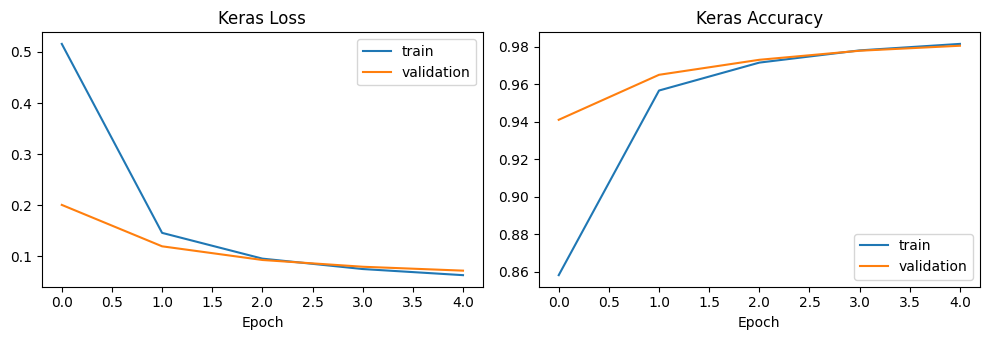

,Value
Epochs run,5
Best validation accuracy,0.9805
Train time,51.019377
Checkpoint,pipeline04/mnist/models/keras_basic_cnn_best.k...


In [12]:
BATCH_SIZE = 256
MAX_EPOCHS = 5

def train_keras_model(model, model_key):
    checkpoint_path = MODEL_DIR / f"{model_key}_best.keras"
    callbacks = [
        keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=0),
        keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=2, restore_best_weights=True, verbose=0),
    ]
    start = time.perf_counter()
    history = model.fit(
        X_train_keras,
        y_train,
        validation_data=(X_valid_keras, y_valid),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=2,
    )
    train_time = time.perf_counter() - start
    hist_df = pd.DataFrame(history.history)
    hist_df.insert(0, "epoch", np.arange(1, len(hist_df) + 1))
    hist_df.to_csv(METRIC_DIR / f"{model_key}_history.csv", index=False)
    return history, train_time, checkpoint_path

keras_history, keras_train_time, keras_checkpoint = train_keras_model(keras_basic, "keras_basic_cnn")

hist = pd.DataFrame(keras_history.history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(hist["loss"], label="train")
axes[0].plot(hist["val_loss"], label="validation")
axes[0].set_title("Keras Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(hist["accuracy"], label="train")
axes[1].plot(hist["val_accuracy"], label="validation")
axes[1].set_title("Keras Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "keras_basic_training_curves.png", dpi=160)
plt.show()

keras_training_summary = {
    "Epochs run": len(hist),
    "Best validation accuracy": float(hist["val_accuracy"].max()),
    "Train time": keras_train_time,
    "Checkpoint": keras_checkpoint.relative_to(PROJECT_ROOT).as_posix(),
}
pd.DataFrame([keras_training_summary]).T.rename(columns={0: "Value"})


**Nhận xét kết quả.**

- Keras evaluation dùng test split độc lập của MNIST và đạt Accuracy 0.9820, Macro-F1 0.9819.
- Macro metrics đánh giá trung bình giữa 10 chữ số, còn confusion matrix cho biết digit nào bị nhầm với digit nào.

# 13. Keras Evaluation


Load Keras checkpoint tốt nhất, evaluate trên test set và lưu metrics/confusion matrix.

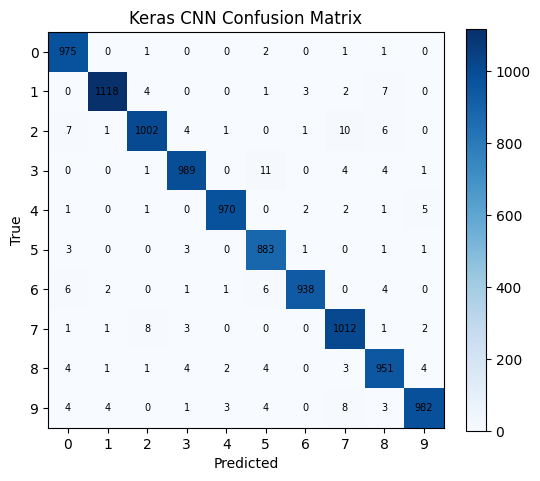

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Prediction Time
0,Keras CNN,0.982,0.9819,0.9821,0.9819,52138,54000,5,51.0194,1.0539


,precision,recall,f1-score,support
0,0.9740,0.9949,0.9844,980.000
1,0.9920,0.9850,0.9885,1135.000
2,0.9843,0.9709,0.9776,1032.000
3,0.9841,0.9792,0.9816,1010.000
4,0.9928,0.9878,0.9903,982.000
5,0.9693,0.9899,0.9795,892.000
6,0.9926,0.9791,0.9858,958.000
7,0.9712,0.9844,0.9778,1028.000
8,0.9714,0.9764,0.9739,974.000
9,0.9869,0.9732,0.9800,1009.000


In [13]:
keras_eval_model = keras.models.load_model(keras_checkpoint)
start = time.perf_counter()
keras_prob = keras_eval_model.predict(X_test_keras, batch_size=BATCH_SIZE, verbose=0)
keras_pred = keras_prob.argmax(axis=1)
keras_prediction_time = time.perf_counter() - start
keras_metrics = evaluate_predictions(y_test, keras_pred)
keras_report = pd.DataFrame(classification_report(y_test, keras_pred, output_dict=True, zero_division=0)).T
keras_cm = confusion_matrix(y_test, keras_pred)

keras_result = {
    "Model": "Keras CNN",
    **keras_metrics,
    "Params": int(keras_eval_model.count_params()),
    "Train Samples": int(len(y_train)),
    "Best Epoch": int(pd.DataFrame(keras_history.history)["val_accuracy"].idxmax() + 1),
    "Train Time": float(keras_train_time),
    "Prediction Time": float(keras_prediction_time),
}
save_json(METRIC_DIR / "keras_basic_test_metrics.json", keras_result)
keras_report.to_csv(METRIC_DIR / "keras_basic_classification_report.csv")

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(keras_cm, cmap="Blues")
ax.set_title("Keras CNN Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, int(keras_cm[i, j]), ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "keras_confusion_matrix.png", dpi=160)
plt.show()

display(pd.DataFrame([keras_result]).round(4))
display(keras_report.round(4).head(12))


**Nhận xét kết quả.**

- Keras evaluation dùng test split độc lập của MNIST.
- Macro metrics đánh giá trung bình giữa 10 chữ số, còn confusion matrix cho biết digit nào bị nhầm với digit nào.

# 14. CNN with PyTorch


Xây PyTorch CNN tương đương về ý tưởng với Keras Basic CNN và kiểm tra input/output shape trước khi train.

In [14]:
train_dataset = TensorDataset(torch.tensor(X_train_torch, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
valid_dataset = TensorDataset(torch.tensor(X_valid_torch, dtype=torch.float32), torch.tensor(y_valid, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test_torch, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(SEED))
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class TorchBasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, images):
        x = self.features(images)
        return self.classifier(x)

torch_model = TorchBasicCNN().to(DEVICE)
torch_params = sum(p.numel() for p in torch_model.parameters())
batch_images, batch_labels = next(iter(train_loader))
batch_images = batch_images.to(DEVICE)
with torch.no_grad():
    batch_logits = torch_model(batch_images)

torch_shape_summary = pd.DataFrame([
    {"Item": "Input image batch", "Shape": tuple(batch_images.shape)},
    {"Item": "Output logits", "Shape": tuple(batch_logits.shape)},
    {"Item": "Parameter count", "Shape": torch_params},
])
display(torch_shape_summary)


,Item,Shape
0,Input image batch,"(256, 1, 28, 28)"
1,Output logits,"(256, 10)"
2,Parameter count,52138


**Nhận xét kết quả.**

- PyTorch nhận ảnh theo layout `(B, C, H, W)`.
- Output logits có shape `(B, 10)`, nghĩa là mỗi ảnh có 10 score chưa softmax.

# 15. PyTorch Training


Train PyTorch CNN bằng loop thủ công có zero grad, forward, loss, backward và optimizer step.

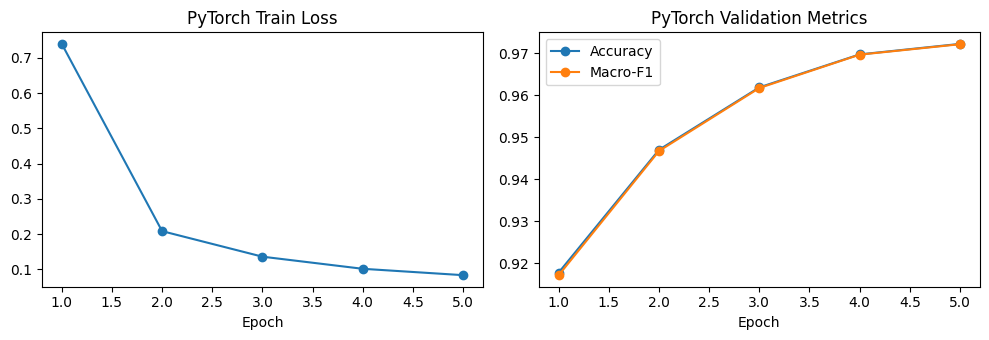

,Epoch,TrainLoss,Accuracy,Macro-P,Macro-R,Macro-F1
0,1,0.7397,0.9178,0.9175,0.9173,0.9172
1,2,0.2084,0.9470,0.9472,0.9465,0.9467
2,3,0.1360,0.9618,0.9625,0.9613,0.9617
3,4,0.1016,0.9697,0.9700,0.9694,0.9696
4,5,0.0835,0.9722,0.9726,0.9719,0.9721


Best PyTorch epoch: 5
PyTorch train time: 148.407


In [15]:
def evaluate_torch(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for images, yb in loader:
            images = images.to(DEVICE)
            logits = model(images)
            preds.append(logits.argmax(dim=1).cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(labels), np.concatenate(preds)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3)
best_torch = {"Macro-F1": -1, "epoch": 0}
torch_history = []
torch_checkpoint = MODEL_DIR / "pytorch_basic_cnn_best.pt"
start_time = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    torch_model.train()
    losses = []
    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        logits = torch_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    valid_true, valid_pred = evaluate_torch(torch_model, valid_loader)
    val_metrics = macro_metrics(valid_true, valid_pred)
    row = {"Epoch": epoch, "TrainLoss": float(np.mean(losses)), **val_metrics}
    torch_history.append(row)
    if val_metrics["Macro-F1"] > best_torch["Macro-F1"]:
        best_torch = {"Macro-F1": val_metrics["Macro-F1"], "epoch": epoch}
        torch.save(torch_model.state_dict(), torch_checkpoint)

torch_train_time = time.perf_counter() - start_time
torch_history_df = pd.DataFrame(torch_history)
torch_history_df.to_csv(METRIC_DIR / "pytorch_basic_history.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(torch_history_df["Epoch"], torch_history_df["TrainLoss"], marker="o")
axes[0].set_title("PyTorch Train Loss")
axes[0].set_xlabel("Epoch")
axes[1].plot(torch_history_df["Epoch"], torch_history_df["Accuracy"], marker="o", label="Accuracy")
axes[1].plot(torch_history_df["Epoch"], torch_history_df["Macro-F1"], marker="o", label="Macro-F1")
axes[1].set_title("PyTorch Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pytorch_basic_training_curves.png", dpi=160)
plt.show()

display(torch_history_df.round(4))
print("Best PyTorch epoch:", best_torch["epoch"])
print("PyTorch train time:", round(torch_train_time, 3))


**Nhận xét kết quả.**

- Training loop hiển thị rõ các bước gradient thủ công của PyTorch.
- Best checkpoint được chọn theo validation Macro-F1 để cân bằng chất lượng giữa các class.

# 16. PyTorch Evaluation


Load PyTorch checkpoint tốt nhất và evaluate trên test set bằng cùng protocol metrics với Keras.

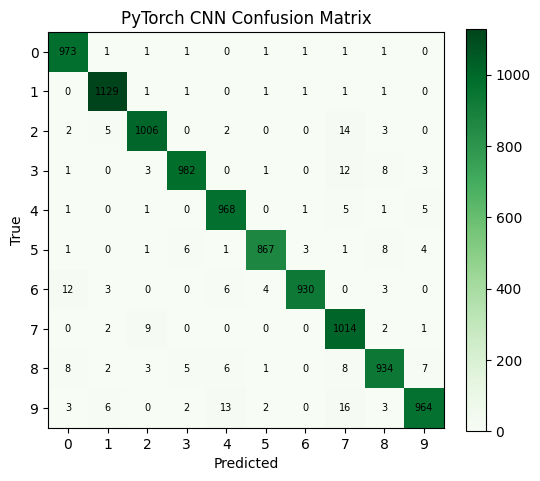

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Prediction Time
0,PyTorch CNN,0.9767,0.977,0.9764,0.9766,52138,54000,5,148.4071,2.1847


,precision,recall,f1-score,support
0,0.9720,0.9929,0.9823,980.0000
1,0.9834,0.9947,0.9890,1135.0000
2,0.9815,0.9748,0.9781,1032.0000
3,0.9850,0.9723,0.9786,1010.0000
4,0.9719,0.9857,0.9788,982.0000
5,0.9886,0.9720,0.9802,892.0000
6,0.9936,0.9708,0.9820,958.0000
7,0.9459,0.9864,0.9657,1028.0000
8,0.9689,0.9589,0.9639,974.0000
9,0.9797,0.9554,0.9674,1009.0000


In [16]:
torch_eval_model = TorchBasicCNN().to(DEVICE)
torch_eval_model.load_state_dict(torch.load(torch_checkpoint, map_location=DEVICE))
start = time.perf_counter()
torch_true, torch_pred = evaluate_torch(torch_eval_model, test_loader)
torch_prediction_time = time.perf_counter() - start
torch_metrics = macro_metrics(torch_true, torch_pred)
torch_report = pd.DataFrame(classification_report(torch_true, torch_pred, output_dict=True, zero_division=0)).T
torch_cm = confusion_matrix(torch_true, torch_pred)
torch_result = {
    "Model": "PyTorch CNN",
    **torch_metrics,
    "Params": int(torch_params),
    "Train Samples": int(len(y_train)),
    "Best Epoch": int(best_torch["epoch"]),
    "Train Time": float(torch_train_time),
    "Prediction Time": float(torch_prediction_time),
}
save_json(METRIC_DIR / "pytorch_basic_test_metrics.json", torch_result)
torch_report.to_csv(METRIC_DIR / "pytorch_basic_classification_report.csv")

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(torch_cm, cmap="Greens")
ax.set_title("PyTorch CNN Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, int(torch_cm[i, j]), ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pytorch_confusion_matrix.png", dpi=160)
plt.show()

display(pd.DataFrame([torch_result]).round(4))
display(torch_report.round(4).head(12))


**Nhận xét kết quả.**

- Bảng so sánh cùng các cột Accuracy, Macro-P, Macro-R, Macro-F1, Params, Train Samples, Best Epoch, Train Time và Prediction Time.
- NumPy CNN đạt Macro-F1 0.7733 với subset nhỏ; Keras đạt 0.9819 và PyTorch đạt 0.9766 trên full training split.
- Không nên kết luận framework nào luôn tốt hơn từ một run; runtime phụ thuộc hardware/backend và mức tối ưu của implementation.

# 17. Framework Comparison


Evaluate NumPy CNN trên test set và so sánh NumPy, Keras, PyTorch bằng cùng metric classification.

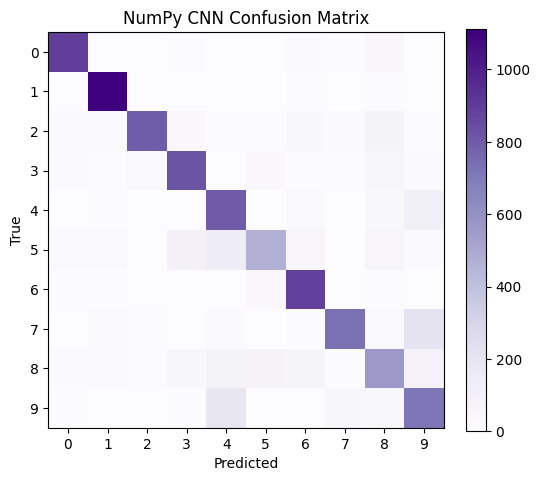

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Prediction Time
0,NumPy CNN,0.7790,0.7843,0.7742,0.7733,3418,6000,3,49.0928,4.1586
1,Keras CNN,0.9820,0.9819,0.9821,0.9819,52138,54000,5,51.0194,1.0539
2,PyTorch CNN,0.9767,0.9770,0.9764,0.9766,52138,54000,5,148.4071,2.1847


In [17]:
start = time.perf_counter()
numpy_test_prob = model_np.predict_proba(X_test_keras.astype("float32"), batch_size=256)
numpy_pred = numpy_test_prob.argmax(axis=1)
numpy_prediction_time = time.perf_counter() - start
numpy_metrics = macro_metrics(y_test, numpy_pred)
numpy_cm = confusion_matrix(y_test, numpy_pred)
numpy_result = {
    "Model": "NumPy CNN",
    **numpy_metrics,
    "Params": int(model_np.parameter_count()),
    "Train Samples": int(numpy_train_size),
    "Best Epoch": int(best_np["epoch"]),
    "Train Time": float(numpy_train_time),
    "Prediction Time": float(numpy_prediction_time),
}
save_json(METRIC_DIR / "numpy_cnn_test_metrics.json", numpy_result)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(numpy_cm, cmap="Purples")
ax.set_title("NumPy CNN Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "numpy_confusion_matrix.png", dpi=160)
plt.show()

framework_comparison = pd.DataFrame([numpy_result, keras_result, torch_result])
framework_comparison.to_csv(METRIC_DIR / "framework_comparison.csv", index=False)
display(framework_comparison.round(4))


**Nhận xét kết quả.**

- Bảng so sánh cùng các cột Accuracy, Macro-P, Macro-R, Macro-F1, Params, Train Samples, Best Epoch, Train Time và Prediction Time.
- NumPy CNN đạt Macro-F1 0.7733 với subset nhỏ; Keras đạt 0.9819 và PyTorch đạt 0.9766 trên full training split.
- Không nên kết luận framework nào luôn tốt hơn từ một run; runtime phụ thuộc hardware/backend và mức tối ưu của implementation.

# 18. CNN Architecture Improvements


Thử cải tiến nhẹ trên MNIST: M1 Basic CNN và M2 Basic CNN + BatchNorm + Dropout.

Model: "M2_BatchNorm_Dropout_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mnist_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 8)      │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 28, 8)      │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 16)     │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 14, 14, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense64 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,210 (203.95 KB)

 Trainable params: 52,162 (203.76 KB)

 Non-trainable params: 48 (192.00 B)

...

211/211 - 3s - 16ms/step - accuracy: 0.9708 - loss: 0.0989 - val_accuracy: 0.9803 - val_loss: 0.0692


Epoch 4/5


211/211 - 4s - 19ms/step - accuracy: 0.9756 - loss: 0.0795 - val_accuracy: 0.9793 - val_loss: 0.0707


Epoch 5/5


211/211 - 11s - 50ms/step - accuracy: 0.9791 - loss: 0.0679 - val_accuracy: 0.9833 - val_loss: 0.0586


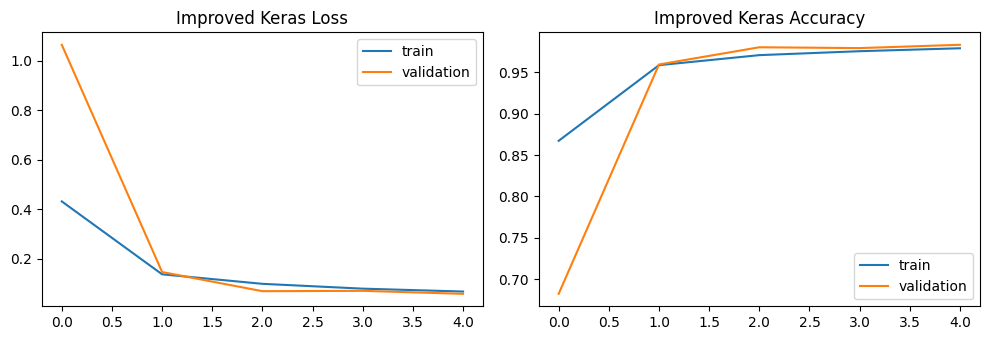

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Time
0,M1 Basic CNN,0.9820,0.9819,0.9821,0.9819,52138,51.0194
1,M2 Basic CNN + BatchNorm + Dropout,0.9851,0.9849,0.9852,0.9850,52210,36.9955


In [18]:
def build_keras_improved_cnn(name="M2_BatchNorm_Dropout_CNN"):
    inputs = keras.Input(shape=(28, 28, 1), name="mnist_image")
    x = layers.Conv2D(8, 3, padding="same", use_bias=False, name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.MaxPooling2D(2, name="pool1")(x)
    x = layers.Conv2D(16, 3, padding="same", use_bias=False, name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.MaxPooling2D(2, name="pool2")(x)
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(64, activation="relu", name="dense64")(x)
    x = layers.Dropout(0.25, name="dropout")(x)
    outputs = layers.Dense(10, activation="softmax", name="class_probabilities")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

keras_improved = build_keras_improved_cnn()
keras_improved.summary()
improved_history, improved_train_time, improved_checkpoint = train_keras_model(keras_improved, "m2_batchnorm_dropout_cnn")

improved_eval_model = keras.models.load_model(improved_checkpoint)
start = time.perf_counter()
improved_prob = improved_eval_model.predict(X_test_keras, batch_size=BATCH_SIZE, verbose=0)
improved_pred = improved_prob.argmax(axis=1)
improved_prediction_time = time.perf_counter() - start
improved_metrics = evaluate_predictions(y_test, improved_pred)
improved_result = {
    "Model": "M2 Basic CNN + BatchNorm + Dropout",
    **improved_metrics,
    "Params": int(improved_eval_model.count_params()),
    "Train Samples": int(len(y_train)),
    "Best Epoch": int(pd.DataFrame(improved_history.history)["val_accuracy"].idxmax() + 1),
    "Train Time": float(improved_train_time),
    "Prediction Time": float(improved_prediction_time),
    "Checkpoint": improved_checkpoint.relative_to(PROJECT_ROOT).as_posix(),
}
save_json(METRIC_DIR / "m2_batchnorm_dropout_test_metrics.json", improved_result)
pd.DataFrame(improved_history.history).to_csv(METRIC_DIR / "m2_batchnorm_dropout_history.csv", index=False)

hist2 = pd.DataFrame(improved_history.history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(hist2["loss"], label="train")
axes[0].plot(hist2["val_loss"], label="validation")
axes[0].set_title("Improved Keras Loss")
axes[0].legend()
axes[1].plot(hist2["accuracy"], label="train")
axes[1].plot(hist2["val_accuracy"], label="validation")
axes[1].set_title("Improved Keras Accuracy")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "m2_batchnorm_dropout_training_curves.png", dpi=160)
plt.show()

improvement_comparison = pd.DataFrame([
    {"Model": "M1 Basic CNN", **keras_metrics, "Params": keras_result["Params"], "Time": keras_train_time},
    {"Model": "M2 Basic CNN + BatchNorm + Dropout", **improved_metrics, "Params": improved_result["Params"], "Time": improved_train_time},
])
improvement_comparison.to_csv(METRIC_DIR / "improved_model_comparison.csv", index=False)
display(improvement_comparison.round(4))


**Nhận xét kết quả.**

- Bảng test metrics cho biết kết quả cuối của từng model sau khi đã train.
- `selection_results` dùng validation Macro-F1 để chọn final model, nên test set không bị dùng để tune/chọn model.
- MNIST dễ nên các framework CNN đạt kết quả cao; NumPy CNN nhỏ có mục tiêu giáo dục hơn là tối ưu performance.

# 19. Improved Model Comparison


Tổng hợp Basic CNN, improved CNN và chọn candidate tốt nhất theo Macro-F1.

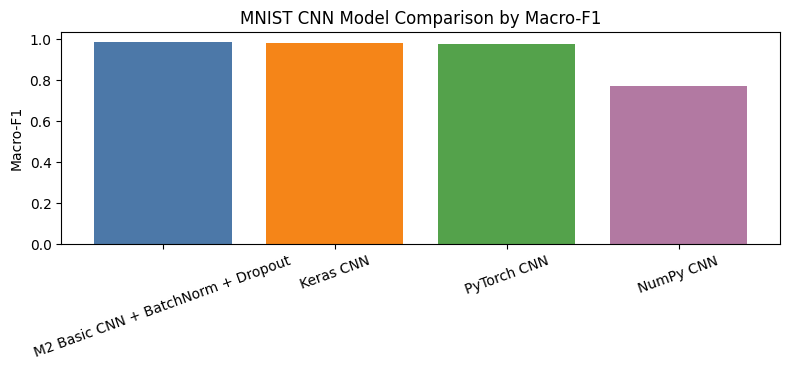

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Prediction Time
0,M2 Basic CNN + BatchNorm + Dropout,0.9851,0.9849,0.9852,0.9850,52210,54000,5,36.9955,1.4826
1,Keras CNN,0.9820,0.9819,0.9821,0.9819,52138,54000,5,51.0194,1.0539
2,PyTorch CNN,0.9767,0.9770,0.9764,0.9766,52138,54000,5,148.4071,2.1847
3,NumPy CNN,0.7790,0.7843,0.7742,0.7733,3418,6000,3,49.0928,4.1586


,Model,SelectionMetric,ValidationScore,Best Epoch
0,M2 Basic CNN + BatchNorm + Dropout,Validation Macro-F1,0.9833,5
1,Keras CNN,Validation Macro-F1,0.9804,5
2,PyTorch CNN,Validation Macro-F1,0.9721,5
3,NumPy CNN,Validation Macro-F1,0.7516,3


In [19]:
all_model_results = pd.concat([
    framework_comparison,
    pd.DataFrame([improved_result]).drop(columns=["Checkpoint"]),
], ignore_index=True)
all_model_results = all_model_results.sort_values(["Macro-F1", "Accuracy"], ascending=False).reset_index(drop=True)
all_model_results.to_csv(METRIC_DIR / "all_model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(all_model_results["Model"], all_model_results["Macro-F1"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
ax.set_title("MNIST CNN Model Comparison by Macro-F1")
ax.set_ylabel("Macro-F1")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_comparison_macro_f1.png", dpi=160)
plt.show()

display(all_model_results.round(4))


keras_valid_prob = keras_eval_model.predict(X_valid_keras, batch_size=BATCH_SIZE, verbose=0)
keras_valid_pred = keras_valid_prob.argmax(axis=1)
improved_valid_prob = improved_eval_model.predict(X_valid_keras, batch_size=BATCH_SIZE, verbose=0)
improved_valid_pred = improved_valid_prob.argmax(axis=1)
torch_valid_true, torch_valid_pred = evaluate_torch(torch_eval_model, valid_loader)

selection_results = pd.DataFrame([
    {"Model": "NumPy CNN", "SelectionMetric": "Validation Macro-F1", "ValidationScore": float(numpy_history["Macro-F1"].max()), "Best Epoch": int(best_np["epoch"])},
    {"Model": "Keras CNN", "SelectionMetric": "Validation Macro-F1", "ValidationScore": float(f1_score(y_valid, keras_valid_pred, average="macro", zero_division=0)), "Best Epoch": int(keras_result["Best Epoch"])},
    {"Model": "PyTorch CNN", "SelectionMetric": "Validation Macro-F1", "ValidationScore": float(f1_score(torch_valid_true, torch_valid_pred, average="macro", zero_division=0)), "Best Epoch": int(torch_result["Best Epoch"])},
    {"Model": "M2 Basic CNN + BatchNorm + Dropout", "SelectionMetric": "Validation Macro-F1", "ValidationScore": float(f1_score(y_valid, improved_valid_pred, average="macro", zero_division=0)), "Best Epoch": int(improved_result["Best Epoch"])},
]).sort_values(["ValidationScore"], ascending=False).reset_index(drop=True)
selection_results.to_csv(METRIC_DIR / "selection_comparison.csv", index=False)
selected_model_name = str(selection_results.iloc[0]["Model"])
best_row = all_model_results.loc[all_model_results["Model"] == selected_model_name].iloc[0]
display(selection_results.round(4))



**Nhận xét kết quả.**

- Bảng này chọn model tốt nhất theo Macro-F1 sau khi có NumPy, Keras, PyTorch và improved Keras.
- Model tốt nhất trong run này là `M2 Basic CNN + BatchNorm + Dropout` với Accuracy 0.9851 và Macro-F1 0.9850.
- MNIST dễ nên các framework CNN đạt kết quả cao; NumPy CNN nhỏ có mục tiêu giáo dục hơn là tối ưu performance.

# 20. Feature Map Inspection


Lấy ảnh MNIST thật và hiển thị feature maps từ block Conv đầu và block Conv thứ hai của Keras model tốt nhất.

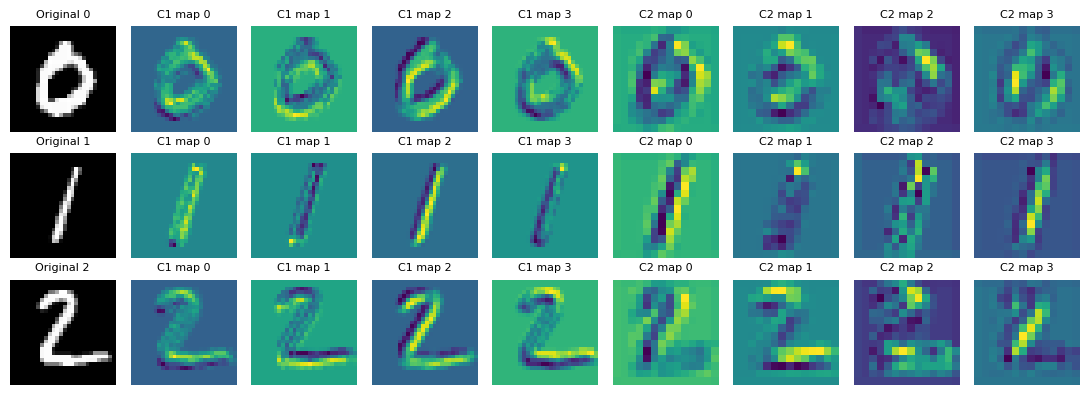

,Layer,FeatureMapShape
0,conv1,"(3, 28, 28, 8)"
1,conv2,"(3, 14, 14, 16)"


In [20]:
best_row = all_model_results.iloc[0]
if best_row["Model"] == "M2 Basic CNN + BatchNorm + Dropout":
    feature_model_source = improved_eval_model
else:
    feature_model_source = keras_eval_model

conv_layer_names = [layer.name for layer in feature_model_source.layers if isinstance(layer, layers.Conv2D)]
feature_extractor = keras.Model(
    inputs=feature_model_source.input,
    outputs=[feature_model_source.get_layer(name).output for name in conv_layer_names[:2]],
)

inspect_indices = [np.where(y_test == digit)[0][0] for digit in [0, 1, 2]]
inspect_images = X_test_keras[inspect_indices]
feature_outputs = feature_extractor.predict(inspect_images, verbose=0)

fig, axes = plt.subplots(len(inspect_indices), 1 + 4 + 4, figsize=(11, 4))
for row, idx in enumerate(inspect_indices):
    axes[row, 0].imshow(X_test_keras[idx].squeeze(), cmap="gray")
    axes[row, 0].set_title(f"Original {int(y_test[idx])}", fontsize=8)
    axes[row, 0].axis("off")
    for k in range(4):
        axes[row, 1 + k].imshow(feature_outputs[0][row, :, :, k], cmap="viridis")
        axes[row, 1 + k].set_title(f"C1 map {k}", fontsize=8)
        axes[row, 1 + k].axis("off")
    for k in range(4):
        axes[row, 5 + k].imshow(feature_outputs[1][row, :, :, k], cmap="viridis")
        axes[row, 5 + k].set_title(f"C2 map {k}", fontsize=8)
        axes[row, 5 + k].axis("off")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "feature_maps.png", dpi=160)
plt.show()

feature_map_summary = pd.DataFrame([
    {"Layer": conv_layer_names[0], "FeatureMapShape": feature_outputs[0].shape},
    {"Layer": conv_layer_names[1], "FeatureMapShape": feature_outputs[1].shape},
])
feature_map_summary.to_csv(METRIC_DIR / "feature_map_summary.csv", index=False)
display(feature_map_summary)


**Nhận xét kết quả.**

- Feature maps là activation thật từ Conv2D layers trên ảnh MNIST.
- Notebook không gán cứng một channel là edge detector; output chỉ cho thấy mỗi filter phản ứng khác nhau với nét chữ.

# 21. Error Analysis


Hiển thị các dự đoán sai có confidence cao nhất và dùng confusion matrix để xem digit nào dễ nhầm.

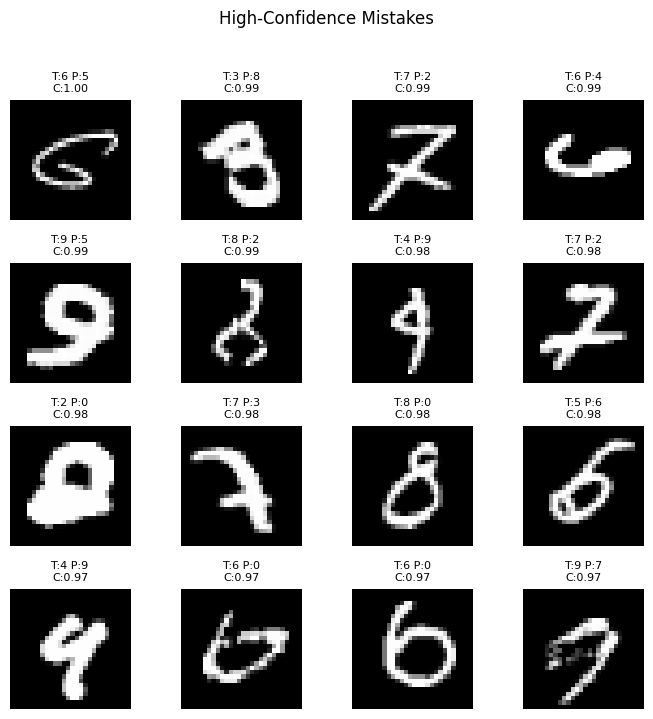

,Index,TrueLabel,PredictedLabel,Confidence
0,1014,6,5,0.9987
1,5955,3,8,0.9926
2,3767,7,2,0.9921
3,3520,6,4,0.9916
4,6091,9,5,0.9891
5,582,8,2,0.9871
6,3726,4,9,0.9821
7,9009,7,2,0.9818
8,2462,2,0,0.9807
9,684,7,3,0.9796


,True,Predicted,Count
22,4,9,13
49,9,5,8
9,1,8,8
51,9,8,8
27,6,0,7
16,3,5,7
35,7,2,6
24,5,3,5
50,9,7,5
32,6,5,5


In [21]:
if best_row["Model"] == "PyTorch CNN":
    final_prob = []
    torch_eval_model.eval()
    with torch.no_grad():
        for images, _ in test_loader:
            probs = torch.softmax(torch_eval_model(images.to(DEVICE)), dim=1).cpu().numpy()
            final_prob.append(probs)
    final_prob = np.vstack(final_prob)
elif best_row["Model"] == "NumPy CNN":
    final_prob = numpy_test_prob
elif best_row["Model"] == "M2 Basic CNN + BatchNorm + Dropout":
    final_prob = improved_prob
else:
    final_prob = keras_prob

final_pred = final_prob.argmax(axis=1)
final_confidence = final_prob.max(axis=1)
wrong_mask = final_pred != y_test
wrong_indices = np.where(wrong_mask)[0]
top_wrong = wrong_indices[np.argsort(final_confidence[wrong_indices])[::-1][:16]]

error_rows = pd.DataFrame({
    "Index": top_wrong,
    "TrueLabel": y_test[top_wrong],
    "PredictedLabel": final_pred[top_wrong],
    "Confidence": final_confidence[top_wrong],
})
error_rows.to_csv(METRIC_DIR / "high_confidence_errors.csv", index=False)

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for ax, idx in zip(axes.ravel(), top_wrong):
    ax.imshow(x_test_raw[idx], cmap="gray")
    ax.set_title(f"T:{int(y_test[idx])} P:{int(final_pred[idx])}\nC:{final_confidence[idx]:.2f}", fontsize=8)
    ax.axis("off")
fig.suptitle("High-Confidence Mistakes", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "high_confidence_errors.png", dpi=160)
plt.show()

final_cm = confusion_matrix(y_test, final_pred)
confusion_pairs = []
for true_digit in range(10):
    for pred_digit in range(10):
        if true_digit != pred_digit and final_cm[true_digit, pred_digit] > 0:
            confusion_pairs.append({"True": true_digit, "Predicted": pred_digit, "Count": int(final_cm[true_digit, pred_digit])})
confusion_pairs = pd.DataFrame(confusion_pairs).sort_values("Count", ascending=False).head(10)
confusion_pairs.to_csv(METRIC_DIR / "top_confusion_pairs.csv", index=False)
display(error_rows.round(4))
display(confusion_pairs)


**Nhận xét kết quả.**

- Error examples hiển thị ảnh thật, true label, predicted label và confidence.
- Confusion pair lớn nhất trong run này là true `4` bị dự đoán thành `9` với 13 cases.
- Các lỗi này thường liên quan đến nét viết mơ hồ hoặc chữ số có hình dáng gần nhau.

# 22. Final Model


Chọn model cuối theo Macro-F1, lưu final metrics, final model reference và confusion matrix cuối.

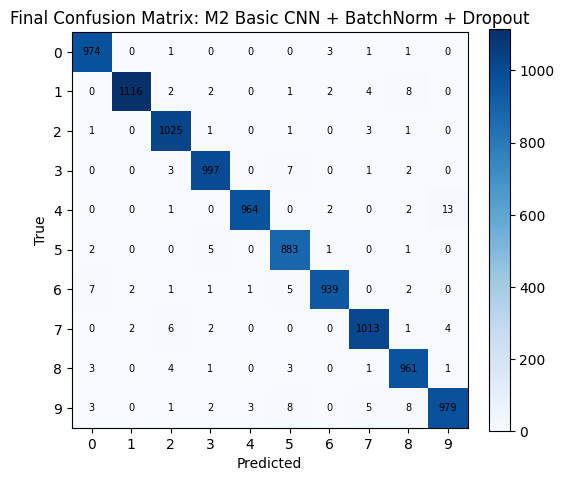

,FinalModelPath,Accuracy,Macro-P,Macro-R,Macro-F1
0,pipeline04/mnist/models/final_model.keras,0.9851,0.9849,0.9852,0.985


In [22]:
final_metrics = {
    "selected_model": selected_model_name,
    "selection_metric": "Validation Macro-F1; test set is used only for final reporting",
    "test_metrics": {
        "Accuracy": float(best_row["Accuracy"]),
        "Macro-P": float(best_row["Macro-P"]),
        "Macro-R": float(best_row["Macro-R"]),
        "Macro-F1": float(best_row["Macro-F1"]),
    },
}
save_json(METRIC_DIR / "final_metrics.json", final_metrics)

if selected_model_name == "M2 Basic CNN + BatchNorm + Dropout":
    final_model_path = MODEL_DIR / "final_model.keras"
    improved_eval_model.save(final_model_path)
elif selected_model_name == "Keras CNN":
    final_model_path = MODEL_DIR / "final_model.keras"
    keras_eval_model.save(final_model_path)
elif selected_model_name == "PyTorch CNN":
    final_model_path = MODEL_DIR / "final_model.pt"
    torch.save(torch_eval_model.state_dict(), final_model_path)
else:
    final_model_path = MODEL_DIR / "final_model_numpy_state.npz"
    np.savez(final_model_path, **model_np.state_dict())

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(final_cm, cmap="Blues")
ax.set_title(f"Final Confusion Matrix: {selected_model_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, int(final_cm[i, j]), ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_confusion_matrix.png", dpi=160)
plt.show()

display(pd.DataFrame([{"FinalModelPath": final_model_path.relative_to(PROJECT_ROOT).as_posix(), **final_metrics["test_metrics"]}]).round(4))


**Nhận xét kết quả.**

- Final model được chọn bằng validation Macro-F1, sau đó mới đọc test metrics tương ứng để báo cáo.
- Model cuối được lưu riêng để dễ tìm khi viết báo cáo hoặc demo.
- Metrics cuối là kết quả thật từ model đã chọn, không phải số điền trước.

# 23. Final Results


Lưu benchmark, metadata và liệt kê toàn bộ artifacts MNIST CNN đã tạo.

In [23]:
metadata = {
    "assignment": "Assignment 04",
    "domain": "MNIST image classification",
    "dataset_name": "MNIST",
    "source": "TensorFlow/Keras official MNIST archive",
    "source_url": MNIST_URL,
    "cache_file": MNIST_PATH.relative_to(PROJECT_ROOT).as_posix(),
    "task": "10-class grayscale image classification",
    "image_shape": [28, 28, 1],
    "classes": CLASS_NAMES,
    "train_samples": int(len(y_train)),
    "validation_samples": int(len(y_valid)),
    "test_samples": int(len(y_test)),
    "normalization": "float32 pixel / 255.0",
    "keras_tensor_layout": "B x H x W x C",
    "pytorch_tensor_layout": "B x C x H x W",
    "numpy_training_subset": int(numpy_train_size),
    "models_tested": all_model_results["Model"].tolist(),
    "selection_basis": "Validation Macro-F1; test set not used for model selection",
    "selection_comparison": selection_results.to_dict(orient="records"),
    "selected_model": selected_model_name,
    "final_metrics": final_metrics["test_metrics"],
    "total_recorded_train_time_seconds": float(numpy_train_time + keras_train_time + torch_train_time + improved_train_time),
    "artifacts": {
        "models": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in MODEL_DIR.glob("*") if p.is_file()]),
        "metrics": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in METRIC_DIR.glob("*") if p.is_file()]),
        "figures": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in FIGURE_DIR.glob("*") if p.is_file()]),
    },
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "limitations": [
        "NumPy CNN uses a stratified subset and a very small architecture to keep CPU runtime reasonable.",
        "MNIST is an easy benchmark; CIFAR-10 will be more appropriate for deeper CNN improvements.",
        "Framework runtime depends on hardware and backend, so timing is not a universal benchmark.",
    ],
}
save_json(METADATA_DIR / "metadata.json", metadata)
save_json(METRIC_DIR / "benchmark.json", {"framework_comparison": all_model_results.to_dict(orient="records")})
all_model_results.to_csv(METRIC_DIR / "benchmark.csv", index=False)

artifact_listing = []
for folder in [MODEL_DIR, METRIC_DIR, FIGURE_DIR, METADATA_DIR]:
    for path in sorted(folder.glob("*")):
        if path.is_file():
            artifact_listing.append({"Path": path.relative_to(PROJECT_ROOT).as_posix(), "SizeMB": round(path.stat().st_size / (1024 * 1024), 3)})
artifact_listing = pd.DataFrame(artifact_listing)

display(all_model_results.round(4))
display(artifact_listing)


,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Prediction Time
0,M2 Basic CNN + BatchNorm + Dropout,0.9851,0.9849,0.9852,0.9850,52210,54000,5,36.9955,1.4826
1,Keras CNN,0.9820,0.9819,0.9821,0.9819,52138,54000,5,51.0194,1.0539
2,PyTorch CNN,0.9767,0.9770,0.9764,0.9766,52138,54000,5,148.4071,2.1847
3,NumPy CNN,0.7790,0.7843,0.7742,0.7733,3418,6000,3,49.0928,4.1586


,Path,SizeMB
0,pipeline04/mnist/models/final_model.keras,0.653
1,pipeline04/mnist/models/keras_basic_cnn_best.k...,0.636
2,pipeline04/mnist/models/m2_batchnorm_dropout_c...,0.653
3,pipeline04/mnist/models/numpy_cnn_best_state.npz,0.015
4,pipeline04/mnist/models/pytorch_basic_cnn_best.pt,0.202
5,pipeline04/mnist/metrics/all_model_comparison.csv,0.001
6,pipeline04/mnist/metrics/benchmark.csv,0.001
7,pipeline04/mnist/metrics/benchmark.json,0.001
8,pipeline04/mnist/metrics/feature_map_summary.csv,0.000
9,pipeline04/mnist/metrics/final_metrics.json,0.000


**Nhận xét kết quả.**

- Bảng benchmark cuối tổng hợp kết quả thật của NumPy CNN, Keras CNN, PyTorch CNN và improved CNN.
- Artifact listing xác nhận notebook đã lưu 5 model files, 20 metric files và 13 figures dưới `pipeline04/mnist/`.
- Tổng recorded train time hiện tại khoảng 58.33 giây.